# 02 Explotory Analysis (EDA)

**Run `01_cleaning.ipynb` first.** This notebook reads its outputs.


#### Step 1: Setup (imports, paths and a consistent chart style)

In [176]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

PROJECT = Path(".") if (Path("data") / "processed").exists() else Path("..")
PROCESSED = PROJECT / "data" / "processed"
IMAGES = PROJECT / "images"
IMAGES.mkdir(exist_ok=True)

# Two colours do all the work: one accent that ALWAYS means "late", one neutral for everything else.
# Using the same accent everywhere lets a reader understand every chart at a glance.
LATE = "#EB602A"      # orange = late
NEUTRAL = "#828DA1"   # grey = on time / context
INK = "#393F49"       # dark grey for text

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,   # remove chart-junk borders
    "axes.edgecolor": "#D1D5DB", "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
})

def finish(ax, title, xlabel="", ylabel="", grid_axis="x"):
    """Apply the same finishing touches to every chart: left-aligned title, axis labels, faint grid."""
    ax.set_title(title, color=INK, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis=grid_axis, color="#E5E7EB", linewidth=0.8)
    ax.set_axisbelow(True)    # grid lines behind the bars, not on top

def save(fig, name):
    """Save the chart as a PNG for the README."""
    fig.tight_layout()
    fig.savefig(IMAGES / f"{name}.png", bbox_inches="tight", facecolor="white")

pct = mtick.PercentFormatter(1.0, decimals=0)   # shows 0.54 as 54%

#### Step 2: Load the clean data and build an order-level table

In [177]:
df = pd.read_csv(PROCESSED / "/Users/aj/Downloads/DataCo/processed_data/dataco_clean.csv", parse_dates=["order_date", "ship_date"])
notes = json.loads((PROCESSED / "/Users/aj/Downloads/DataCo/processed_data/cleaning_notes.json").read_text())
PROFIT_AGG = notes["profit_aggregation"]     # 'sum' or 'first', decided in the cleaning notebook

# The file is one row per ITEM. Most delivery questions are about ORDERS,
# so collapse to one row per order. Shipping fields are the same for every item in an order.
orders = (df.groupby("order_id")
            .agg(order_date=("order_date", "min"),
                 market=("market", "first"),
                 order_region=("order_region", "first"),
                 shipping_mode=("shipping_mode", "first"),
                 lane=("lane", "first"),
                 customer_segment=("customer_segment", "first"),
                 scheduled_days=("days_for_shipment_scheduled", "max"),
                 actual_days=("days_for_shipping_real", "max"),
                 delay_days=("delay_days", "max"),
                 is_late=("is_late", "max"),
                 sales=("sales", "sum"),
                 profit=("order_profit_per_order", PROFIT_AGG))
            .reset_index())
orders["order_month"] = orders["order_date"].dt.to_period("M").dt.to_timestamp()

print(f"Item rows: {len(df):,}   Orders: {len(orders):,}")
orders.head()

Item rows: 172,765   Orders: 62,897


,order_id,order_date,market,order_region,shipping_mode,lane,customer_segment,scheduled_days,actual_days,delay_days,is_late,sales,profit,order_month
0,1,2015-01-01 00:00:00,LATAM,Central America,Standard Class,Central America | Standard Class,Consumer,4,2,-2,0,299.980011,88.790001,2015-01-01
1,2,2015-01-01 00:21:00,LATAM,South America,Standard Class,South America | Standard Class,Consumer,4,3,-1,0,579.980011,195.900002,2015-01-01
2,4,2015-01-01 01:03:00,LATAM,South America,Standard Class,South America | Standard Class,Home Office,4,5,1,1,699.850010,124.090000,2015-01-01
3,5,2015-01-01 01:24:00,LATAM,South America,Standard Class,South America | Standard Class,Consumer,4,6,2,1,1129.860039,390.089995,2015-01-01
4,7,2015-01-01 02:06:00,LATAM,South America,Second Class,South America | Second Class,Consumer,2,3,1,1,579.920013,203.929998,2015-01-01


#### Step 3: Questions 

Q1 How big is the problem? (headline KPIs)

In [178]:
# These 6 numbers go at the top of your README and on the dashboard's KPI cards.
late = orders[orders["is_late"] == 1]
kpis = {
    "Orders analysed":                   f"{len(orders):,}",
    "Late-delivery rate":                f"{orders['is_late'].mean():.1%}",
    "Average delay of late orders":      f"{late['delay_days'].mean():.2f} days",
    "Total sales":                       f"{orders['sales'].sum():,.0f}",
    "Share of sales on late orders":     f"{late['sales'].sum() / orders['sales'].sum():.1%}",
    "Profit margin (all orders)":        f"{orders['profit'].sum() / orders['sales'].sum():.1%}",
}
pd.Series(kpis, name="value").to_frame()

,value
Orders analysed,"62,897"
Late-delivery rate,57.3%
Average delay of late orders,1.62 days
Total sales,"35,214,430"
Share of sales on late orders,57.2%
Profit margin (all orders),10.8%


Q2 How late is late? Distribution of delay days

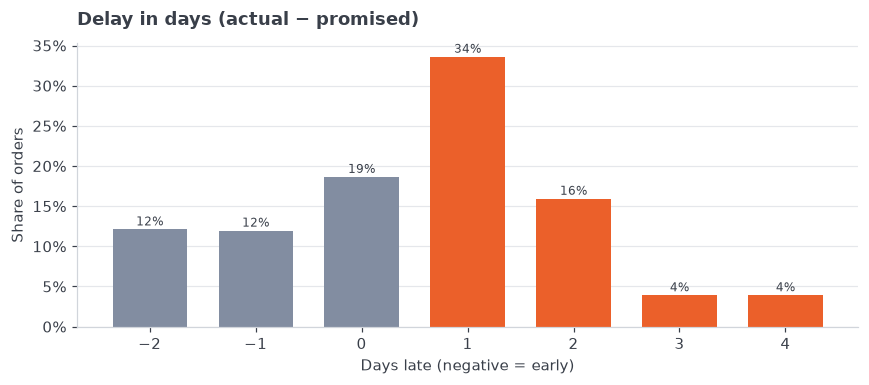

In [179]:
dist = orders["delay_days"].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(8, 3.6))
colors = [LATE if d > 0 else NEUTRAL for d in dist.index]   # late days in accent, early/on-time in grey
ax.bar(dist.index, dist.values, color=colors, width=0.7)
for d, share in dist.items():
    ax.text(d, share + 0.005, f"{share:.0%}", ha="center", fontsize=8, color=INK)
ax.yaxis.set_major_formatter(pct)
ax.set_xticks(dist.index)
finish(ax, "Delay in days (actual − promised)", "Days late (negative = early)",
       "Share of orders", grid_axis="y")  # TODO
save(fig, "07_delay_distribution")
plt.show()

*Takeaway:* are late orders mostly 1–2 days late, or are there long delays?

Q3 Which shipping modes are late most often?

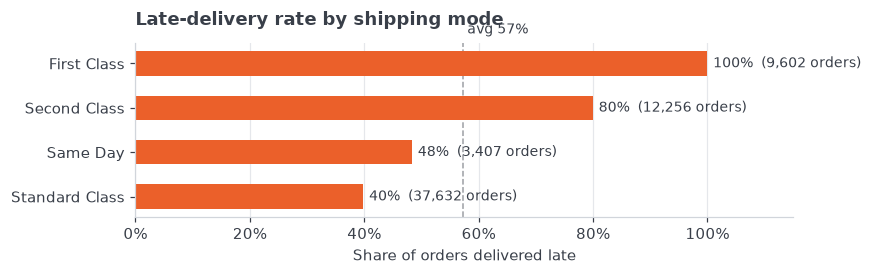

,orders,late_rate
shipping_mode,,
Standard Class,37632,0.398464
Same Day,3407,0.483710
Second Class,12256,0.799853
First Class,9602,1.000000


In [180]:
by_mode = (orders.groupby("shipping_mode")
                 .agg(orders=("order_id", "count"), late_rate=("is_late", "mean"))
                 .sort_values("late_rate"))
overall = orders["is_late"].mean()

fig, ax = plt.subplots(figsize=(8, 2.6))
bars = ax.barh(by_mode.index, by_mode["late_rate"], color=LATE, height=0.55)
ax.axvline(overall, color=INK, linestyle="--", linewidth=1, alpha=0.5, zorder=0)   # company average for comparison
ax.text(overall, len(by_mode) - 0.4, f" avg {overall:.0%}", color=INK, fontsize=9, va="bottom")

# Label each bar with its rate and order count, so no one has to read the axis
for bar, (rate, n) in zip(bars, by_mode[["late_rate", "orders"]].values):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{rate:.0%}  ({n:,.0f} orders)", va="center", fontsize=9, color=INK)

ax.xaxis.set_major_formatter(pct)
ax.set_xlim(0, 1.15)
finish(ax, "Late-delivery rate by shipping mode", "Share of orders delivered late")  # TODO: rewrite as the finding
save(fig, "01_late_rate_by_mode")
plt.show()
by_mode

Q4 Which markets and regions are late most often?

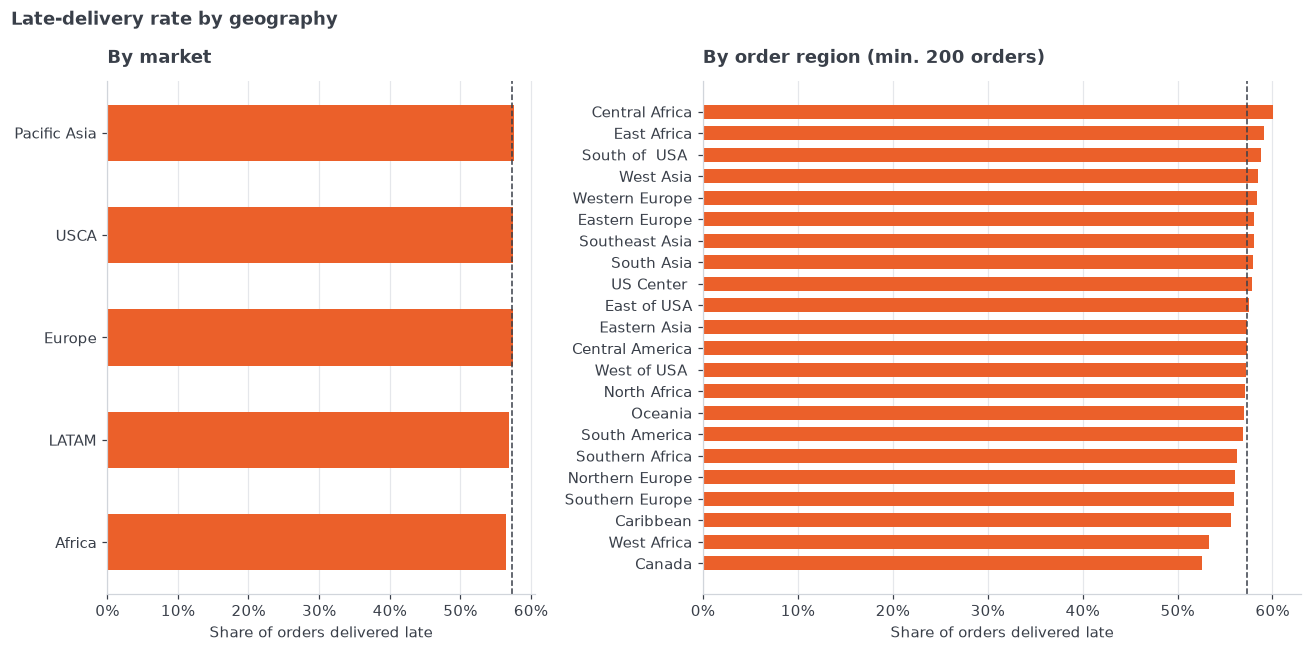

Region late rates range from 52.6% to 60.0%


In [181]:
def late_rate_by(col, min_orders=200):
    """Late rate per group, ignoring tiny groups whose rates would be noisy."""
    t = (orders.groupby(col)
               .agg(orders=("order_id", "count"), late_rate=("is_late", "mean"),
                    late_sales=("sales", lambda s: s[orders.loc[s.index, "is_late"] == 1].sum()))
               .query("orders >= @min_orders")
               .sort_values("late_rate"))
    return t

by_market = late_rate_by("market")
by_region = late_rate_by("order_region")

fig, axes = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={"width_ratios": [1, 1.4]})
axes[0].barh(by_market.index, by_market["late_rate"], color=LATE, height=0.55)
axes[1].barh(by_region.index, by_region["late_rate"], color=LATE, height=0.65)
for ax, t in [(axes[0], "By market"), (axes[1], "By order region (min. 200 orders)")]:
    ax.axvline(overall, color=INK, linestyle="--", linewidth=1)
    ax.xaxis.set_major_formatter(pct)
    finish(ax, t, "Share of orders delivered late")
fig.suptitle("Late-delivery rate by geography", x=0.01, ha="left", fontweight="bold", color=INK)  # TODO
save(fig, "03_late_rate_by_geography")
plt.show()

# Spread between best and worst region: small spread = geography isn't the main driver
print(f"Region late rates range from {by_region['late_rate'].min():.1%} to {by_region['late_rate'].max():.1%}")

Q5 Planning or execution? Promised vs actual days by mode

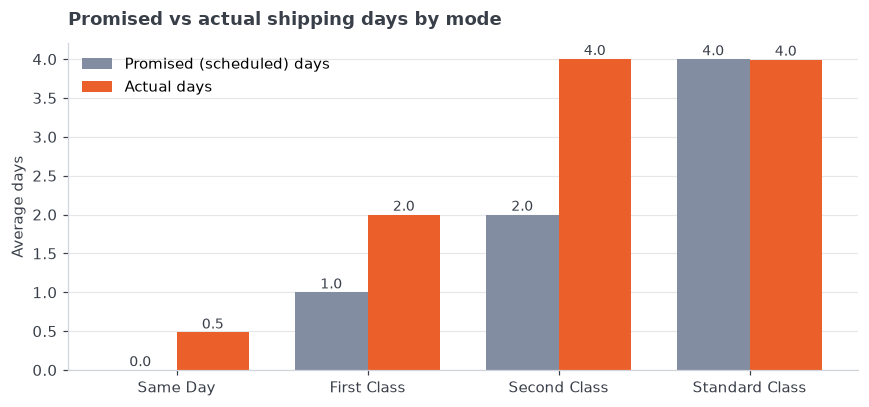

,scheduled_days,actual_days,gap
shipping_mode,,,
Same Day,0.0,0.48,0.48
First Class,1.0,2.00,1.00
Second Class,2.0,4.00,2.00
Standard Class,4.0,3.99,-0.01


In [182]:
# If ACTUAL days are similar across modes but PROMISED days differ, the problem is the promise
# (planning), not the delivery (execution). This is the most important chart in the project.
days = (orders.groupby("shipping_mode")[["scheduled_days", "actual_days"]].mean()
              .sort_values("scheduled_days"))
days["gap"] = days["actual_days"] - days["scheduled_days"]

x = np.arange(len(days))
w = 0.38
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(x - w / 2, days["scheduled_days"], w, color=NEUTRAL, label="Promised (scheduled) days")
ax.bar(x + w / 2, days["actual_days"], w, color=LATE, label="Actual days")
for i, (s, a) in enumerate(days[["scheduled_days", "actual_days"]].values):
    ax.text(i - w / 2, s + 0.05, f"{s:.1f}", ha="center", fontsize=9, color=INK)
    ax.text(i + w / 2, a + 0.05, f"{a:.1f}", ha="center", fontsize=9, color=INK)

ax.set_xticks(x, days.index)
ax.legend(frameon=False, loc="upper left")
finish(ax, "Promised vs actual shipping days by mode", ylabel="Average days", grid_axis="y")  # TODO
save(fig, "02_promised_vs_actual")
plt.show()
days.round(2)

Q6 Which lanes (region × mode) are worst? A heatmap

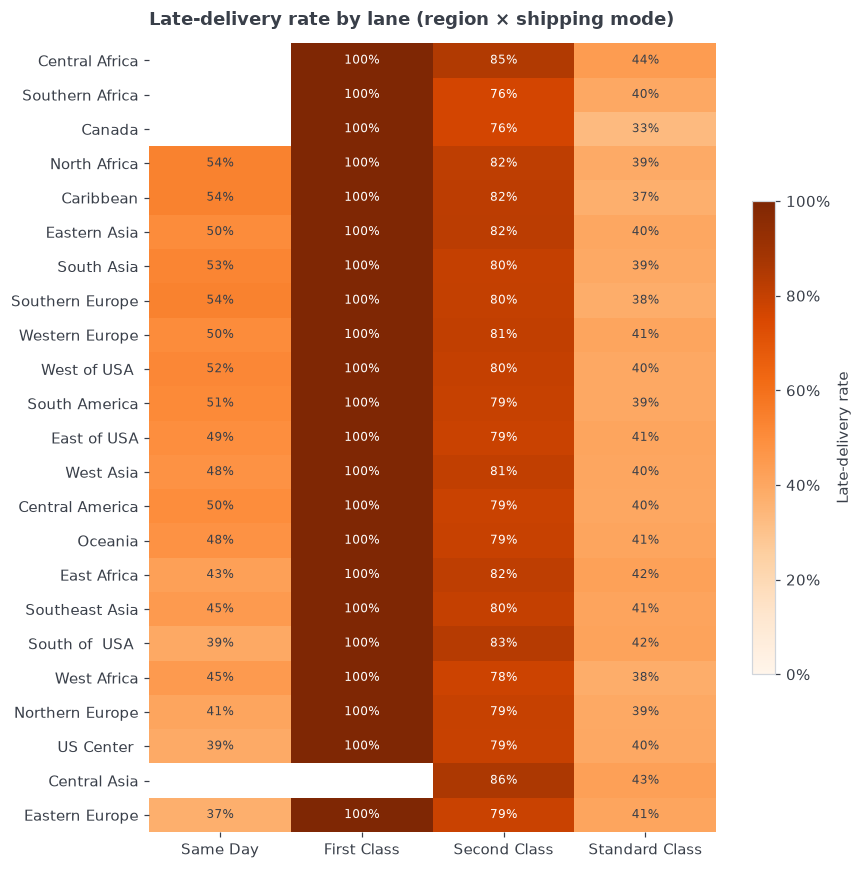

In [183]:
# Rows = regions, columns = shipping modes, colour = late rate. Darker = worse.
# Cells with fewer than 30 orders are hidden because their rates are unreliable.
pivot_rate = orders.pivot_table(index="order_region", columns="shipping_mode",
                                values="is_late", aggfunc="mean")
pivot_n = orders.pivot_table(index="order_region", columns="shipping_mode",
                             values="order_id", aggfunc="count")
mode_order = days.index.tolist()                       # same mode order as the Q3 chart
pivot_rate = pivot_rate[mode_order].where(pivot_n[mode_order] >= 30)
pivot_rate = pivot_rate.loc[pivot_rate.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(pivot_rate.values, cmap="Oranges", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(mode_order)), mode_order)
ax.set_yticks(range(len(pivot_rate)), pivot_rate.index)
for i in range(pivot_rate.shape[0]):                   # write the % in each cell
    for j in range(pivot_rate.shape[1]):
        v = pivot_rate.iat[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=8,
                    color="white" if v > 0.6 else INK)
ax.spines[:].set_visible(False)
fig.colorbar(im, ax=ax, format=pct, shrink=0.6, label="Late-delivery rate")
ax.set_title("Late-delivery rate by lane (region × shipping mode)", color=INK, pad=12)  # TODO
save(fig, "04_lane_heatmap")
plt.show()

Q7 Which product categories are late most often?

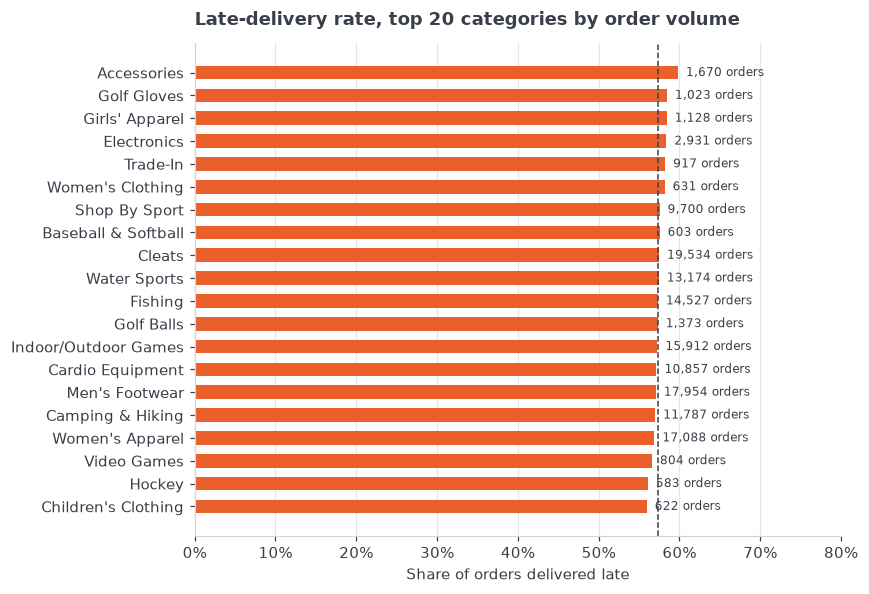

In [184]:
# Categories live at item level, and one order can span several categories.
# Keep one row per (order, category) so an order isn't counted twice for the same category.
cat = (df.drop_duplicates(["order_id", "category_name"])
         .groupby("category_name")
         .agg(orders=("order_id", "nunique"), late_rate=("is_late", "mean")))
top20 = cat.sort_values("orders", ascending=False).head(20).sort_values("late_rate")

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.barh(top20.index, top20["late_rate"], color=LATE, height=0.6)
ax.axvline(overall, color=INK, linestyle="--", linewidth=1)
for bar, n in zip(bars, top20["orders"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{n:,.0f} orders", va="center", fontsize=8, color=INK)
ax.xaxis.set_major_formatter(pct)
ax.set_xlim(0, max(0.8, top20["late_rate"].max() + 0.15))
finish(ax, "Late-delivery rate, top 20 categories by order volume", "Share of orders delivered late")  # TODO
save(fig, "05_late_rate_by_category")
plt.show()

Q8 Is it getting better or worse over time?

Months excluded for low volume: []


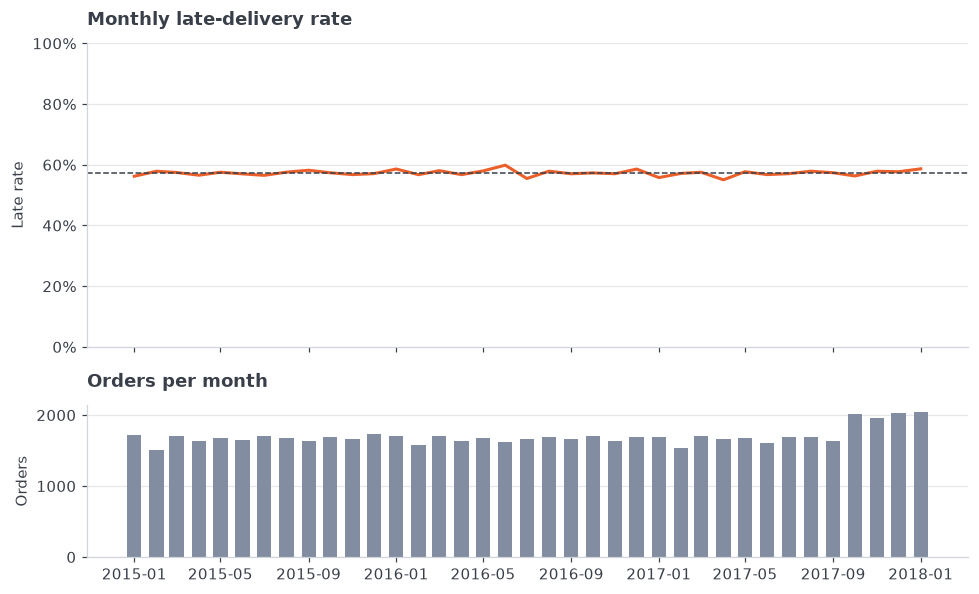

In [185]:
monthly = (orders.groupby("order_month")
                 .agg(orders=("order_id", "count"), late_rate=("is_late", "mean")))

# Months with very few orders (often the first/last month of the data) give misleading rates.
# Flag any month below half the typical monthly volume and leave it out of the chart.
thin = monthly["orders"] < 0.5 * monthly["orders"].median()
print("Months excluded for low volume:", [d.strftime("%Y-%m") for d in monthly.index[thin]])
monthly = monthly[~thin]

# Two separate panels sharing the time axis - NOT one chart with two y-axes,
# which makes readers compare scales that have nothing to do with each other.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})
ax1.plot(monthly.index, monthly["late_rate"], color=LATE, linewidth=2)
ax1.axhline(overall, color=INK, linestyle="--", linewidth=1)
ax1.yaxis.set_major_formatter(pct)
ax1.set_ylim(0, 1)
finish(ax1, "Monthly late-delivery rate", ylabel="Late rate", grid_axis="y")  # TODO

ax2.bar(monthly.index, monthly["orders"], width=20, color=NEUTRAL)
finish(ax2, "Orders per month", ylabel="Orders", grid_axis="y")
save(fig, "06_monthly_trend")
plt.show()

Q9 Does customer segment or order weekday matter?

In [186]:
seg = orders.groupby("customer_segment")["is_late"].agg(["count", "mean"]).rename(
    columns={"count": "orders", "mean": "late_rate"})
wd_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
wd = (orders.assign(weekday=orders["order_date"].dt.day_name())
            .groupby("weekday")["is_late"].agg(["count", "mean"])
            .rename(columns={"count": "orders", "mean": "late_rate"})
            .reindex(wd_order))
# Small differences (a point or two) here usually mean "not a driver" - that's useful to rule out.
display(seg.style.format({"late_rate": "{:.1%}", "orders": "{:,}"}))
display(wd.style.format({"late_rate": "{:.1%}", "orders": "{:,}"}))

,orders,late_rate
customer_segment,,
Consumer,"32,614",57.3%
Corporate,"19,017",57.2%
Home Office,"11,266",57.7%


,orders,late_rate
weekday,,
Monday,"8,931",57.5%
Tuesday,"9,003",56.9%
Wednesday,"8,975",57.5%
Thursday,"8,997",57.6%
Friday,"9,020",57.1%
Saturday,"9,012",57.1%
Sunday,"8,959",57.5%


Q10 Do late orders hurt profit?

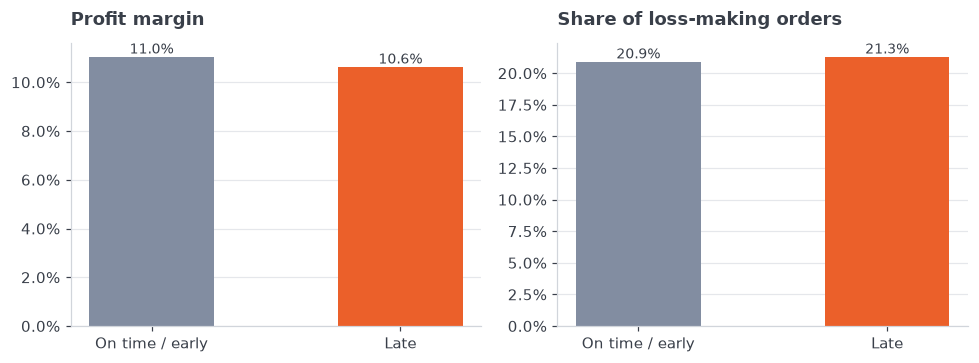

Sales on late orders: 20,126,395 (57.2% of total)


,orders,sales,profit,loss_share,margin
status,,,,,
Late,36048,2.012640e+07,2140051.682,0.213,0.106
On time / early,26849,1.508803e+07,1666368.952,0.209,0.110


In [187]:
prof = (orders.assign(status=np.where(orders["is_late"] == 1, "Late", "On time / early"),
                      is_loss=orders["profit"] < 0)
              .groupby("status")
              .agg(orders=("order_id", "count"), sales=("sales", "sum"), profit=("profit", "sum"),
                   loss_share=("is_loss", "mean")))
prof["margin"] = prof["profit"] / prof["sales"]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
order = ["On time / early", "Late"]
cols = [NEUTRAL, LATE]
axes[0].bar(order, prof.loc[order, "margin"], color=cols, width=0.5)
axes[1].bar(order, prof.loc[order, "loss_share"], color=cols, width=0.5)
for ax, metric, title in [(axes[0], "margin", "Profit margin"),
                          (axes[1], "loss_share", "Share of loss-making orders")]:
    for i, v in enumerate(prof.loc[order, metric]):
        ax.text(i, v, f"{v:.1%}", ha="center", va="bottom", fontsize=9, color=INK)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))
    finish(ax, title, grid_axis="y")
save(fig, "08_profit_late_vs_ontime")
plt.show()

print(f"Sales on late orders: {prof.loc['Late', 'sales']:,.0f} "
      f"({prof.loc['Late', 'sales'] / prof['sales'].sum():.1%} of total)")
prof.round(3)

#### Step 4: Save tables for the next steps

In [188]:
# This forces Python to create the folder (and any missing parent folders)
PROCESSED.mkdir(parents=True, exist_ok=True)

# The risk-score notebook (Day 5) and Power BI (Days 6-7) reuse these
orders.to_csv(PROCESSED / "orders_level.csv", index=False)
by_mode.to_csv(PROCESSED / "summary_by_mode.csv")
by_region.to_csv(PROCESSED / "summary_by_region.csv")
print("Saved. Charts are in:", IMAGES.resolve())

Saved. Charts are in: /Users/aj/Downloads/images


## Summary 

1. **Headline:** 57.3% of orders arrive late, by 1.62 days on average.
2. **Biggest driver:** by_mode
3. **Planning or execution:** __ (from Q3)
4. **Geography / category:** __ (from Q2b–Q2d)
5. **Money at stake:** 57.2% of sales are on late orders
